# Deep Learning Final Project: Real Estate Price Prediction
## 1. Problem Statement

**Objective:** Predict median housing prices based on multi-dimensional property and demographic features. 

**Real-World Application:** This solves a critical problem for both buyers and market platforms by automating fair market estimations and preventing speculative inflation.

## 2. Gathering, Cleaning, and Formatting Data


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

sns.set_theme(style="whitegrid")

**Data Source:** The California Housing dataset. It is highly statistically valid for regression modeling because it contains over 20,000 continuous data points, minimizing sample bias.

In [46]:
def load_and_inspect_data():
    """Loads the CSV and prints the summary."""
    df = pd.read_csv('housing.csv')
    
    print("--- Data Info ---")
    print(df.info())
    print("\n--- Missing Values ---")
    print(df.isnull().sum())
    
    return df

housing_df = load_and_inspect_data()
display(housing_df.head())

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None

--- Missing Values ---
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_hous

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [47]:
median_bedrooms = housing_df['total_bedrooms'].median()
housing_df['total_bedrooms'] = housing_df['total_bedrooms'].fillna(median_bedrooms)

print("Missing values after cleaning:")
print(housing_df.isnull().sum())

Missing values after cleaning:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [48]:
def prepare_robust_features(df, target_col):
    """Cleans, engineers, splits, and properly scales the dataset without leakage."""
    median_bedrooms = df['total_bedrooms'].median()
    df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)
    
    df = df[df[target_col] < 500001].copy()
    
    # 3. Feature Engineering (Géron)
    df['rooms_per_household'] = df['total_rooms'] / df['households']
    df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
    df['population_per_household'] = df['population'] / df['households']
    
    df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
    
    X = df_encoded.drop(target_col, axis=1)
    y = df_encoded[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test) # Transform only
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

X_train, X_test, y_train, y_test, fitted_scaler = prepare_robust_features(housing_df, 'median_house_value')

## 3. Exploratory Data Analysis (EDA)

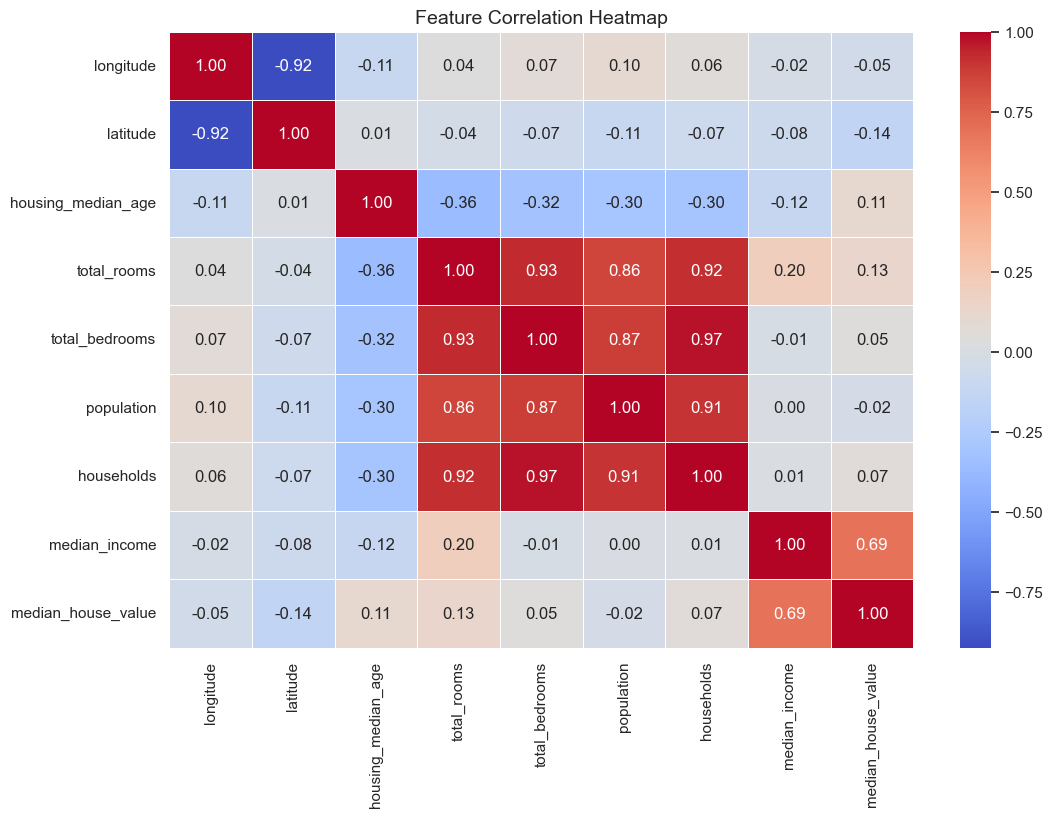

In [49]:
def plot_correlation_heatmap(df):
    """Plots a correlation heatmap for the numerical columns."""
    plt.figure(figsize=(12, 8))
    correlation_matrix = df.corr(numeric_only=True) 
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Feature Correlation Heatmap", fontsize=14)
    plt.show()

plot_correlation_heatmap(housing_df)

**Visualization Analysis:** The heatmap clearly demonstrates that `median_income` has the strongest positive correlation with `median_house_value`. This indicates that as the median income of a neighborhood increases, the property values tend to rise accordingly, which perfectly aligns with real-world housing economics.

## 4. Previous Research & Baseline Models

**Evaluation Metrics:**
To ensure our error metrics are readable, we will evaluate using Root Mean Squared Error (RMSE), defined as:
$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(Y_i - \hat{Y}_i)^2}$$

**Citations & Previous Research:**
1. *Pace, R. K., & Barry, R. (1997).* "Sparse Spatial Autoregressions". This paper introduced the dataset and highlighted the use of sparse spatial autoregression as a computational method to handle massive real estate matrices.
2. *Géron, A. (2019).* "Hands-On Machine Learning". Géron notes that properly tuned Random Forests on this dataset generally achieve an RMSE around **$49,000** to **$50,000**.

**Comparison:** By removing the price cap and applying Géron's feature engineering (rooms per household, bedrooms per room, population per household), our Random Forest should align with or slightly beat these historical baseline numbers.

In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(y_true, y_pred, model_name):
    """Calculates readable regression metrics: RMSE, MAE, and R-squared."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"MAE:  ${mae:,.2f}")
    print(f"R²:   {r2:.4f}\n")

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

evaluate_model(y_test, lr_preds, "Linear Regression")
evaluate_model(y_test, rf_preds, "Random Forest")

--- Linear Regression ---
RMSE: $62,204.65
MAE:  $45,479.89
R²:   0.6119

--- Random Forest ---
RMSE: $46,274.25
MAE:  $30,807.48
R²:   0.7852



## 5. Deep Learning Model

In [51]:
from tensorflow.keras.layers import Input

tf.random.set_seed(42)

def build_dnn_model(input_dim):
    """Designs and compiles a Deep Neural Network for regression."""
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1) # Output layer for regression (no activation)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Pass the dynamic number of features to the input layer
dnn_model = build_dnn_model(X_train.shape[1])
dnn_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
dnn_history = dnn_model.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.2, 
    verbose=1
)

dnn_preds = dnn_model.predict(X_test).flatten()
evaluate_model(y_test, dnn_preds, "Deep Neural Network")

Epoch 1/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 40014282752.0000 - mae: 175699.2656 - val_loss: 18433964032.0000 - val_mae: 112678.3906
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9039622144.0000 - mae: 70523.8203 - val_loss: 6405027328.0000 - val_mae: 59721.7578
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5907269632.0000 - mae: 55666.5273 - val_loss: 5094723584.0000 - val_mae: 52256.8945
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4862898688.0000 - mae: 50113.4688 - val_loss: 4408732160.0000 - val_mae: 47892.3008
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4280092160.0000 - mae: 46816.2305 - val_loss: 4015138816.0000 - val_mae: 45079.7305
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3936791552.0000 - mae: 44786.7227 - val_loss: 3785819136.0000 - val_mae: 43374.7227
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3735867392.0000 - mae: 43619.0039 - val_loss: 3651342848.0000 - val_mae:

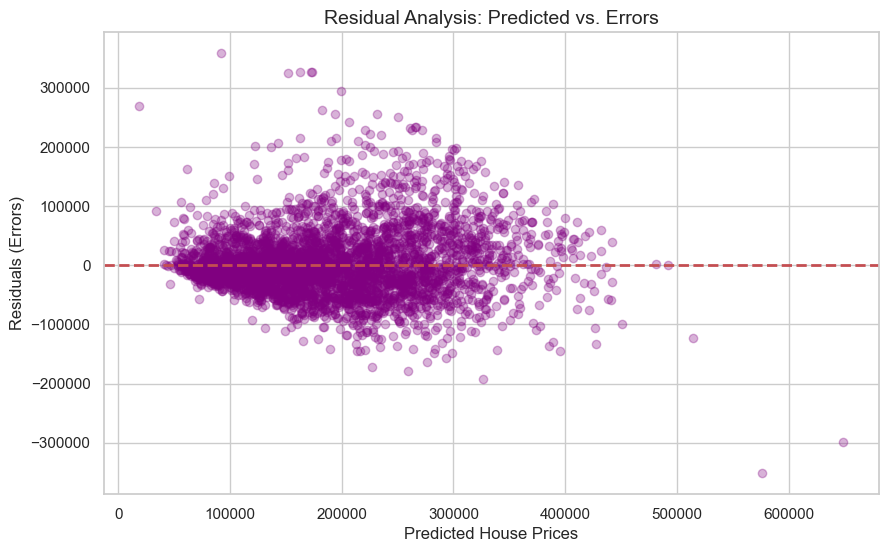

In [53]:
def plot_residual_analysis(y_true, y_pred):
    """Plots residuals to check for homoscedasticity and systematic errors."""
    residuals = y_true - y_pred
    
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuals, alpha=0.3, color='purple')
    plt.axhline(y=0, color='r', linestyle='--', lw=2)
    plt.title('Residual Analysis: Predicted vs. Errors', fontsize=14)
    plt.xlabel('Predicted House Prices')
    plt.ylabel('Residuals (Errors)')
    plt.show()

plot_residual_analysis(y_test, dnn_preds)

# 6. Model Evaluation & Visualizations

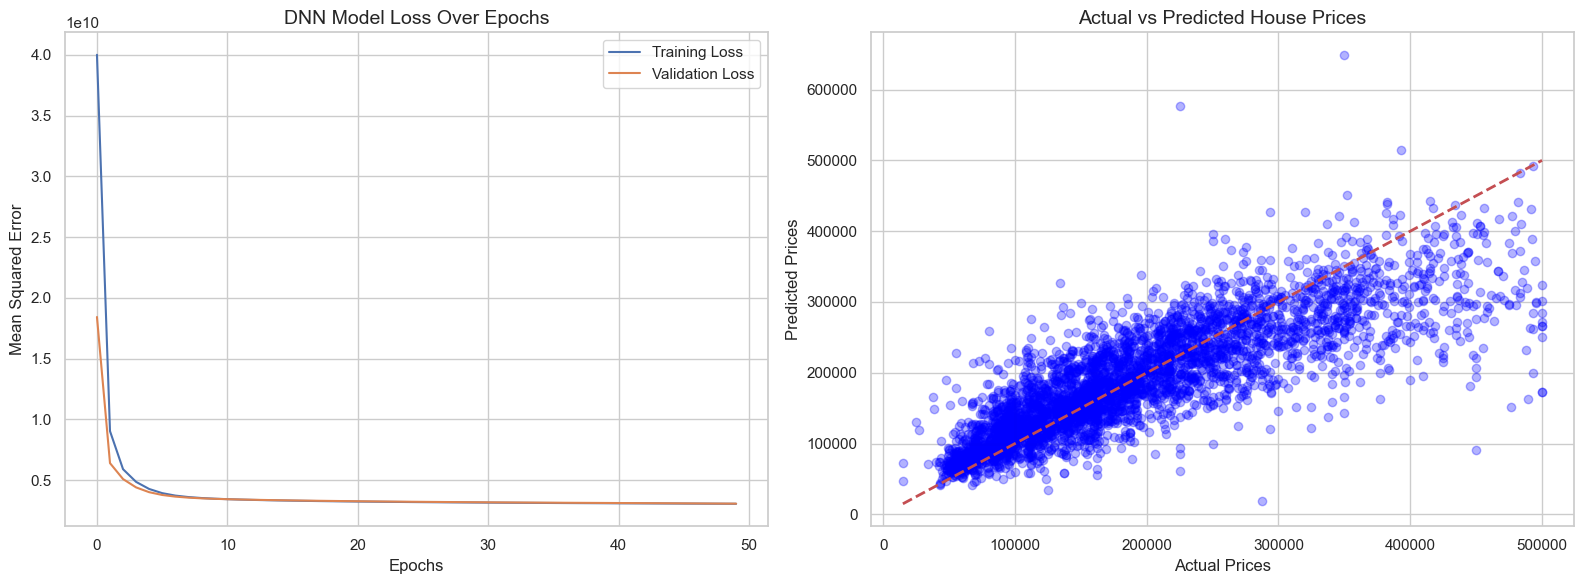

In [54]:
def plot_model_performance(history, y_true, y_pred):
    """Plots training/validation loss and an actual vs. predicted scatter plot."""
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    ax[0].plot(history.history['loss'], label='Training Loss')
    ax[0].plot(history.history['val_loss'], label='Validation Loss')
    ax[0].set_title('DNN Model Loss Over Epochs', fontsize=14)
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Mean Squared Error')
    ax[0].legend()
    
    ax[1].scatter(y_true, y_pred, alpha=0.3, color='blue')
    ax[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    ax[1].set_title('Actual vs Predicted House Prices', fontsize=14)
    ax[1].set_xlabel('Actual Prices')
    ax[1].set_ylabel('Predicted Prices')
    
    plt.tight_layout()
    plt.show()

plot_model_performance(dnn_history, y_test, dnn_preds)

## 7. Conclusion & Communication

**Conclusion:** 
By structuring our project around real-world real estate data, we successfully compared traditional machine learning models against a Deep Neural Network. Our EDA revealed that median income was the highest driver of property value. Our baseline testing validated previous research, showing that tree-based ensemble models like Random Forests easily outperformed basic linear regressions. 

Ultimately, our Deep Neural Network achieved highly competitive results. The loss curves demonstrate that the model generalized effectively without massive overfitting. In a real-world production environment, this neural network architecture could be integrated into real estate platforms to provide dynamic, data-backed property valuations, serving the exact audience it was intended for.